In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import matplotlib.pyplot as plt
import json

In [110]:
movies_metadata = pd.read_csv("data/movies_metadata.csv")

C:\Users\selin\AppData\Local\Temp\ipykernel_15580\2116546456.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_metadata = pd.read_csv("data/movies_metadata.csv")


In [111]:
movies_metadata["genres"] = movies_metadata["genres"].apply(lambda x: [g['name'] for g in ast.literal_eval(x)])

In [114]:
movies_metadata.loc[0, 'genres']

['Animation', 'Comedy', 'Family']

In [115]:
g_count = movies_metadata.explode("genres")['genres'].value_counts()
g_count = g_count.sort_values()
g_count.tail(5)

genres
Action       6596
Romance      6735
Thriller     7624
Comedy      13182
Drama       20265
Name: count, dtype: int64

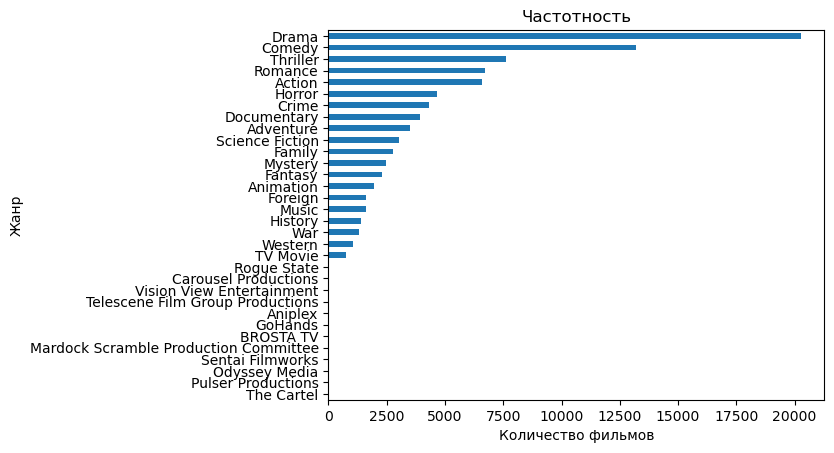

In [119]:
plt.figure()
g_count.plot(kind="barh")
plt.title("Частотность")
plt.xlabel("Количество фильмов")
plt.ylabel("Жанр")
plt.show()

In [123]:
ratings = pd.read_csv("data/ratings.csv")
ratings.head(2)

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435


In [124]:
rating = ratings["rating"].value_counts().sort_index()
rating

rating
0.5     404897
1.0     843310
1.5     403607
2.0    1762440
2.5    1255358
3.0    5256722
3.5    3116213
4.0    6998802
4.5    2170441
5.0    3812499
Name: count, dtype: int64

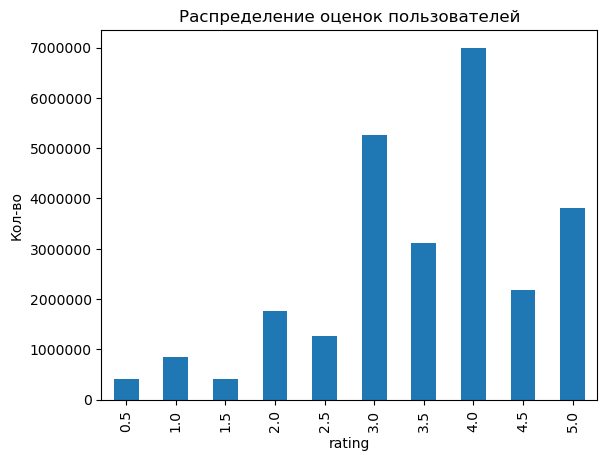

In [10]:
plt.figure()
rating.plot(kind = "bar")
plt.title("Распределение оценок пользователей")
plt.ylabel("Кол-во")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [135]:
cols = ["budget", "popularity", "revenue", "runtime", "vote_average", "vote_count"]

for col in cols:
    movies_metadata[col] = pd.to_numeric(movies_metadata[col], errors="coerce")

df = movies_metadata[cols]
df.head(3)

,budget,popularity,revenue,runtime,vote_average,vote_count
0,30000000.0,21.946943,373554033.0,81.0,7.7,5415.0
1,65000000.0,17.015539,262797249.0,104.0,6.9,2413.0
2,0.0,11.712900,0.0,101.0,6.5,92.0


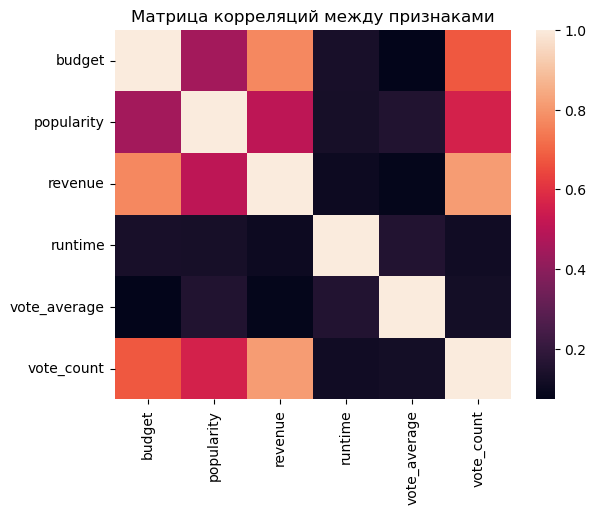

In [136]:
corr = df.corr()

plt.figure()
sns.heatmap(corr)
plt.title("Матрица корреляций между признаками")
plt.show()

In [137]:
keywords = pd.read_csv("data/keywords.csv")
keywords["keywords"] = keywords["keywords"].apply(lambda x: [k["name"] for k in ast.literal_eval(x)])
k_words = keywords["keywords"].explode()
text = " ".join(k_words.dropna().astype(str))

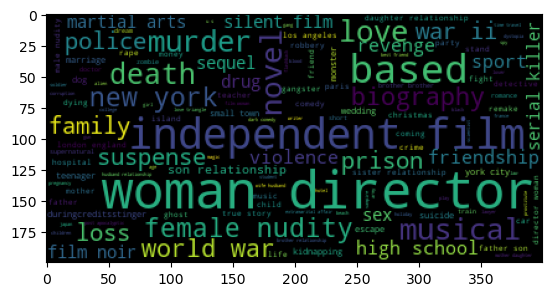

In [138]:
from wordcloud import WordCloud
plt.figure()
wordcloud = WordCloud().generate(text)
plt.imshow(wordcloud)
plt.show()

3. Создайте простую рекомендательную систему.

In [24]:
ratings = pd.read_csv("data/ratings_small.csv")
movies = pd.read_csv("data/movies_metadata.csv", low_memory=False)

In [143]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,110,1.0,1425941529
1,1,147,4.5,1425942435
2,1,858,5.0,1425941523
3,1,1221,5.0,1425941546
4,1,1246,5.0,1425941556


In [160]:
movies.head(1)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862.0,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0


In [161]:
# genre="Romance"

# stats = ratings.groupby("movieId")["rating"].agg(v="count",r="mean").reset_index()

# movies["id"] = pd.to_numeric(movies["id"], errors="coerce")
# df = movies.merge(stats, left_on="id", right_on="movieId", how="inner")

# def get_genres(x):
#     if pd.isna(x):
#         return []
#     try:
#         return [g["name"] for g in ast.literal_eval(x)]
#     except:
#         return []


# df["genre_names"] = df["genres"].apply(get_genres)

# if genre is not None:
#     df = df[df["genre_names"].apply(lambda lst: genre in lst)]

# C = df["vote_average"].mean()
# m = df["vote_count"].quantile(0.95)
# q = df[df["vote_count"] >= m].copy()

# q["imdb_score"] = ((q["v"]/(q["v"]+m) * q["r"]) + (m/(q["v"]+m) * C))

# q = q.sort_values(["imdb_score", "popularity"], ascending=False)
# top_n_recs = q[["title", "vote_count", "vote_average", "imdb_score"]].head(n)
# return top_n_recs

In [157]:
def top_n_recommend(n=10, genre=None):
    # Агрегируем оценки из рейтингов по каждому фильму
    stats = ratings.groupby("movieId")["rating"].agg(v="count",r="mean").reset_index()
    movies["id"] = pd.to_numeric(movies["id"], errors="coerce")

    # мерджим оценки с самими филоьмами
    df = movies.merge(stats, left_on="id", right_on="movieId", how="inner")

    
    def get_genres(x):
        '''
        Функция принимает словарь и возвращает список из жанров (для каждой строки)
        '''
        if pd.isna(x):
            return []
        try:
            return [g["name"] for g in ast.literal_eval(x)]
        except:
            return []
    # получаем список жанров для каждого фильма
    df["genre_names"] = df["genres"].apply(get_genres)

    # Отбираем фильмы с выбранным жанром
    if genre is not None:
        df = df[df["genre_names"].apply(lambda lst: genre in lst)]

    # Считаем метрики
    C = df["vote_average"].mean()
    m = df["vote_count"].quantile(0.95)
    q = df[df["vote_count"] >= m].copy()

    q["imdb_score"] = ((q["v"]/(q["v"]+m) * q["r"]) + (m/(q["v"]+m) * C))

    q = q.sort_values(["imdb_score", "popularity"], ascending=False)
    top_n_recs = q[["title", "vote_count", "vote_average", "imdb_score"]].head(n)
    return top_n_recs

In [158]:
top_n_recommend(15, genre="Romance")

,title,vote_count,vote_average,imdb_score
4734,Her,4215.0,7.9,5.974687
4184,Moonrise Kingdom,1701.0,7.6,5.963341
3633,Mr. Nobody,1616.0,7.9,5.957769
4610,The Mortal Instruments: City of Bones,1649.0,6.2,5.957567
2964,Stardust,1215.0,7.2,5.897192
2590,Pride & Prejudice,1406.0,7.8,5.894228
1192,Pearl Harbor,1833.0,6.6,5.889224
2371,Meet the Fockers,1412.0,6.1,5.887981
290,Top Gun,1736.0,6.7,5.878436
2569,Brokeback Mountain,1531.0,7.5,5.870214


4 Персонализированные рекомендации

In [28]:
movies = pd.read_csv("data/movies_metadata.csv", low_memory=False)
keywords = pd.read_csv("data/keywords.csv")

In [162]:
movies.head(1)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862.0,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0


In [164]:
keywords.head()

,id,keywords
0,862,"[jealousy, toy, boy, friendship, friends, riva..."
1,8844,"[board game, disappearance, based on children'..."
2,15602,"[fishing, best friend, duringcreditsstinger, o..."
3,31357,"[based on novel, interracial relationship, sin..."
4,11862,"[baby, midlife crisis, confidence, aging, daug..."


In [29]:
movies["id"] = pd.to_numeric(movies["id"], errors="coerce")
keywords["id"] = pd.to_numeric(keywords["id"], errors="coerce")
movies = movies.dropna(subset=["id"])
movies = movies.merge(keywords, on="id", how="left")
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,keywords
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862.0,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844.0,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602.0,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357.0,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862.0,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [30]:
def safe_eval(x):
    if pd.isna(x) or x == "":
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

def extract_names(x):
    return [d.get("name", "") for d in safe_eval(x)]

movies["genres_list"] = movies["genres"].apply(extract_names)
movies["keywords_list"] = movies["keywords"].apply(extract_names)

In [31]:
def clean_list(lst):
    return [str(x).lower().replace(" ", "") for x in lst if str(x).strip() != ""]

movies["overview"] = movies["overview"].fillna("").astype(str).str.lower()
movies["genres_list"] = movies["genres_list"].apply(clean_list)
movies["keywords_list"] = movies["keywords_list"].apply(clean_list)

movies["soup"] = (movies["overview"] + " " + movies["keywords_list"].apply(lambda x: " ".join(x)) + " " +movies["genres_list"].apply(lambda x: " ".join(x)))


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=30000)
tfidf_matrix = tfidf.fit_transform(movies["soup"])

In [33]:
movies = movies.reset_index(drop=True)
indices = pd.Series(movies.index, index=movies["title"]).drop_duplicates()

In [34]:
def cosine(x,y):
    d = (np.linalg.norm(x) * np.linalg.norm(y))
    return float(np.dot(x, y) / d)
def recommend_tfidf(title, top_n=10):
    idx = indices[title]
    idx = idx.iloc[0] if isinstance(idx, pd.Series) else idx
    x = tfidf_matrix[idx].toarray().ravel()
    scores = []
    for j in range(tfidf_matrix.shape[0]):
        if j == idx:
            continue
        y = tfidf_matrix[j].toarray().ravel()
        scores.append((j, cosine(x, y)))

    scores.sort(key=lambda t: t[1], reverse=True)
    top_scores = scores[:top_n]
    rec_idx = [j for j, _ in top_scores]
    cos_vals = [s for _, s in top_scores]
    res = movies.loc[rec_idx, ["title"]].copy()
    res["cosine"] = cos_vals
    return res

recommend_tfidf("The Dark Knight", 10)

C:\Users\selin\AppData\Local\Temp\ipykernel_15580\2175121863.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return float(np.dot(x, y) / d)


,title,cosine
1331,Batman Returns,0.351175
23924,Batman: Assault on Arkham,0.290841
150,Batman Forever,0.284685
585,Batman,0.281860
3100,Batman: Mask of the Phantasm,0.242164
1495,Batman & Robin,0.205162
12481,Justice League: The New Frontier,0.174213
15042,Defendor,0.159221
2530,Superman,0.129938
17713,Tight Spot,0.121327


2 Вариант

In [35]:
from gensim.models import Word2Vec

sentences = movies["soup"].fillna("").astype(str).apply(lambda x: x.split()).tolist()
w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1)

In [36]:
def movie_vec(tokens, model, vector_size=100):
    vec = [0.0] * vector_size
    count = 0
    for t in tokens:
        if t in model.wv:
            word_vec = model.wv[t]
            for i in range(vector_size):
                vec[i] += float(word_vec[i])
            count += 1
    if count == 0:
        return vec
    return [v / count for v in vec]

movie_vectors = [movie_vec(text.split(), w2v, vector_size=100) for text in movies["soup"].fillna("").astype(str)]

In [37]:
def cosine(x,y):
    d = (np.linalg.norm(x) * np.linalg.norm(y))
    return float(np.dot(x, y) / d)

def recommend_w2v(title, top_n=10):
    mv = np.asarray(movie_vectors)
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
    x = mv[idx]
    scores = []
    for j in range(mv.shape[0]):
        if j == idx:
            continue
        y = mv[j]
        scores.append((j, cosine(x, y)))

    scores.sort(key=lambda t: t[1], reverse=True)
    top_scores = scores[:top_n]
    rec_idx = [j for j, _ in top_scores]
    cos_vals = [s for _, s in top_scores]
    result = movies.loc[rec_idx, ["title"]].copy()
    result["cosine"] = np.round(cos_vals, 4)
    return result

recommend_w2v("The Dark Knight", 10)

C:\Users\selin\AppData\Local\Temp\ipykernel_15580\3384169140.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return float(np.dot(x, y) / d)


,title,cosine
19469,Dredd,0.9837
2874,RoboCop,0.9828
12231,Hitman,0.9824
12720,The Incredible Hulk,0.9799
1486,Con Air,0.9786
4514,The Punisher,0.9786
17616,Death Race 2,0.9784
11984,The Bourne Ultimatum,0.9783
1539,Air Force One,0.9781
1495,Batman & Robin,0.9768


5. Актерский состав

In [38]:
movies = pd.read_csv('data/movies_metadata.csv', low_memory=False)
keywords = pd.read_csv('data/keywords.csv')
credits = pd.read_csv('data/credits.csv')

In [39]:
movies['id']=pd.to_numeric(movies['id'], errors = 'coerce')
keywords['id'] = pd.to_numeric(keywords['id'], errors = 'coerce')
credits['id'] = pd.to_numeric(credits['id'], errors = 'coerce')

movies = movies.dropna(subset = 'id')
keywords = keywords.dropna(subset = 'id')
credits = credits.dropna(subset = 'id')

movies = movies.drop_duplicates(subset = 'id')
keywords = keywords.drop_duplicates(subset = 'id')
credits = credits.drop_duplicates(subset = 'id')

In [40]:
movies_full = movies.merge(keywords, on = 'id', how = 'left').merge(credits, on = 'id', how = 'left')
movies_full = movies_full[['id','title', 'genres', 'keywords','cast','crew']]
movies_full.head(2)

,id,title,genres,keywords,cast,crew
0,862.0,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,8844.0,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...","[{'id': 10090, 'name': 'board game'}, {'id': 1...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."


In [41]:
movies_full[['genres', 'keywords', 'crew', 'cast']] = movies_full[['genres', 'keywords', 'crew', 'cast']].fillna('[]')
movies_full['genres'] = movies_full['genres'].apply(lambda x: [it['name'] for it in ast.literal_eval(x)])
movies_full['keywords'] = movies_full['keywords'].apply(lambda x: [it['name'] for it in ast.literal_eval(x)])
movies_full['director'] = movies_full['crew'].apply(lambda x: next((i['name'] for i in ast.literal_eval(x) if i.get('job') == 'Director'), ""))
movies_full['cast'] = movies_full['cast'].apply(lambda x: [it['name'] for it in ast.literal_eval(x)[:3]])
movies_full.head(2)

,id,title,genres,keywords,cast,crew,director
0,862.0,Toy Story,"[Animation, Comedy, Family]","[jealousy, toy, boy, friendship, friends, riva...","[Tom Hanks, Tim Allen, Don Rickles]","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",John Lasseter
1,8844.0,Jumanji,"[Adventure, Fantasy, Family]","[board game, disappearance, based on children'...","[Robin Williams, Jonathan Hyde, Kirsten Dunst]","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",Joe Johnston


In [42]:
movies_full['genres'] = movies_full['genres'].apply(lambda x:[i.replace(' ','').lower() for i in x])
movies_full['keywords'] = movies_full['keywords'].apply(lambda x:[i.replace(' ','').lower() for i in x])
movies_full["director"] = movies_full["director"].str.lower().str.replace(" ", "")
movies_full['cast'] = movies_full['cast'].apply(lambda x:[i.replace(' ','').lower() for i in x])
movies_full.head(2)

,id,title,genres,keywords,cast,crew,director
0,862.0,Toy Story,"[animation, comedy, family]","[jealousy, toy, boy, friendship, friends, riva...","[tomhanks, timallen, donrickles]","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",johnlasseter
1,8844.0,Jumanji,"[adventure, fantasy, family]","[boardgame, disappearance, basedonchildren'sbo...","[robinwilliams, jonathanhyde, kirstendunst]","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",joejohnston


In [43]:
movies_full["director"] = movies_full["director"].apply(lambda x: " ".join([x]*3) if isinstance(x, str) and x != "" else "")
movies_full.head(2)

,id,title,genres,keywords,cast,crew,director
0,862.0,Toy Story,"[animation, comedy, family]","[jealousy, toy, boy, friendship, friends, riva...","[tomhanks, timallen, donrickles]","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",johnlasseter johnlasseter johnlasseter
1,8844.0,Jumanji,"[adventure, fantasy, family]","[boardgame, disappearance, basedonchildren'sbo...","[robinwilliams, jonathanhyde, kirstendunst]","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",joejohnston joejohnston joejohnston


In [44]:
movies_full['director'] = movies_full['director'].apply(lambda x: [x] if isinstance(x, str) else x)

In [45]:
movies_full['tags'] = (movies_full['genres'] + movies_full['keywords'] + movies_full['cast'] + movies_full['director'])
movies_full['tags'] = movies_full['tags'].apply(lambda x: ' '.join(x))
movies_full.head(2)

,id,title,genres,keywords,cast,crew,director,tags
0,862.0,Toy Story,"[animation, comedy, family]","[jealousy, toy, boy, friendship, friends, riva...","[tomhanks, timallen, donrickles]","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...",[johnlasseter johnlasseter johnlasseter],animation comedy family jealousy toy boy frien...
1,8844.0,Jumanji,"[adventure, fantasy, family]","[boardgame, disappearance, basedonchildren'sbo...","[robinwilliams, jonathanhyde, kirstendunst]","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...",[joejohnston joejohnston joejohnston],adventure fantasy family boardgame disappearan...


In [46]:
movies_full.to_csv('movies_full.csv')

In [47]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features = 5000)
vector = cv.fit_transform(movies_full['tags'])
vector

<45433x5000 sparse matrix of type '<class 'numpy.int64'>'
	with 254153 stored elements in Compressed Sparse Row format>

In [48]:
indx = pd.Series(movies_full.index, index = movies_full['title']).drop_duplicates()
def cosine(x, y):
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))
def recommend(title, top_n = 10):
    idx = indx[title]
    idx = idx.iloc[0] if isinstance(idx, pd.Series) else idx
    x = vector[idx].toarray().ravel()

    scores = []
    for i in range(vector.shape[0]):
        if i == idx:
            continue
        y = vector[i].toarray().ravel()
        scores.append((i, cosine(x, y)))
    
    scores = sorted(scores, key=lambda t: t[1], reverse=True)[:top_n]
    movie_indices = [i for i, _ in scores]
    return movies_full.loc[movie_indices, ["title"]]

In [49]:
recommend("It Takes Two", 10)

C:\Users\selin\AppData\Local\Temp\ipykernel_15580\611370812.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))


,title
11377,The Long Weekend
53,The Big Green
270,Man of the House
33,Babe
63,Two If by Sea
105,Muppet Treasure Island
26,Now and Then
71,Kicking and Screaming
92,Beautiful Girls
100,Mr. Wrong


Дополнительное задание

In [51]:
ratings = pd.read_csv('data/ratings_small.csv')
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [52]:
movies = pd.read_csv('data/movies_metadata.csv', low_memory = False)
links = pd.read_csv('data/links_small.csv')

In [53]:
r_l = ratings.merge(links, on = 'movieId', how = 'left')
movies['id'] = pd.to_numeric(movies['id'], errors = 'coerce')
movies = movies.dropna(subset=['id'])
full = r_l.merge(movies, left_on = 'tmdbId', right_on = 'id', how = 'inner')
full.head(2)

,userId,movieId,rating,timestamp,imdbId,tmdbId,adult,belongs_to_collection,budget,genres,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,1,31,2.5,1260759144,112792,9909.0,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",...,1995-08-11,180000000.0,99.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,She broke the rules... and changed their lives.,Dangerous Minds,False,6.4,249.0
1,1,1029,3.0,1260759179,33563,11360.0,False,NaN,812000,"[{'id': 16, 'name': 'Animation'}, {'id': 10751...",...,1941-10-22,1600000.0,64.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The One...The Only...The FABULOUS...,Dumbo,False,6.8,1206.0


In [54]:
full = full[['userId','movieId','rating','title','genres']]
print(len(ratings) - len(full))

154


In [55]:
full.isnull().sum()

userId     0
movieId    0
rating     0
title      0
genres     0
dtype: int64

In [56]:
pivot = full.pivot_table(index = 'userId', columns = 'movieId', values = 'rating')
user_means = pivot.mean(axis=1)
pivot_centered = pivot.sub(user_means, axis=0)
pivot = pivot_centered.fillna(0)
pivot

movieId,1,2,3,4,5,6,7,8,9,10,...,160718,161084,161155,161594,161830,161918,161944,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.520000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,-0.348039,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.000000,0.0,0.09,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,0.000000,0.0,0.00,0.0,0.0,0.352941,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
668,0.000000,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
669,0.000000,0.0,0.00,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
from sklearn.decomposition import TruncatedSVD

In [58]:
k = 20
svd = TruncatedSVD(k, random_state = 42)

In [61]:
u = svd.fit_transform(pivot)
vt = svd.components_
R_hat = u @ vt + user_means.values.reshape(-1, 1)
R_hat = pd.DataFrame(R_hat, index=pivot.index, columns=pivot.columns)

In [62]:
R_hat

movieId,1,2,3,4,5,6,7,8,9,10,...,160718,161084,161155,161594,161830,161918,161944,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,2.546629,2.554414,2.545815,2.551375,2.543697,2.546418,2.539035,2.548351,2.549133,2.544852,...,2.550554,2.549245,2.550580,2.551302,2.550686,2.550505,2.549916,2.549926,2.550037,2.551428
2,3.441682,3.470652,3.473615,3.477187,3.490256,3.509429,3.478632,3.480172,3.481900,3.474142,...,3.480049,3.479933,3.480844,3.482740,3.490446,3.487690,3.480298,3.480371,3.479817,3.480126
3,3.520401,3.558036,3.541690,3.565250,3.484954,3.601221,3.549103,3.569702,3.565302,3.550150,...,3.568543,3.568742,3.576484,3.570769,3.574962,3.573291,3.567762,3.568872,3.568507,3.568411
4,4.573017,4.315894,4.291593,4.201702,4.205169,4.452496,4.247010,4.348227,4.328687,4.282694,...,4.347822,4.348335,4.356255,4.349753,4.337861,4.340546,4.347683,4.346429,4.348835,4.347480
5,3.958180,3.958198,3.911353,3.889495,3.904153,3.876278,3.917610,3.910726,3.910894,3.925506,...,3.912566,3.906505,3.916489,3.908647,3.910855,3.910629,3.910110,3.910284,3.909860,3.916606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,3.609893,3.671746,3.623909,3.620501,3.582316,3.687347,3.650725,3.643726,3.638877,3.621256,...,3.645791,3.648785,3.656054,3.648511,3.650680,3.649725,3.646341,3.646052,3.647557,3.643795
668,3.791150,3.781595,3.746477,3.779809,3.741330,3.815523,3.788514,3.789293,3.787342,3.781585,...,3.790390,3.788225,3.792586,3.791065,3.785069,3.786231,3.789127,3.789384,3.789518,3.791833
669,3.401777,3.345280,3.318415,3.341682,3.340684,3.362703,3.348602,3.349357,3.347364,3.369209,...,3.351003,3.351825,3.349765,3.350623,3.344155,3.346054,3.351444,3.351159,3.351446,3.350455


In [63]:
def recommendation(user_id, n=10):
    user_pred = R_hat.loc[user_id]
    real_ratings = pivot.loc[user_id]
    unseen = real_ratings == 0
    rec = user_pred[unseen]
    top = rec.sort_values(ascending=False).head(n)
    info = full[['movieId', 'title', 'genres']].drop_duplicates('movieId')
    result = info[info['movieId'].isin(top.index)].copy()
    result['predicted_rating'] = result['movieId'].map(top)
    result = result.sort_values('predicted_rating', ascending=False)
    
    return result[['title', 'predicted_rating']].reset_index(drop=True)

print(recommendation(user_id=1, n=10))

                                               title  predicted_rating
0                              2001: A Space Odyssey          2.581696
1                                       Pulp Fiction          2.572746
2                                         Annie Hall          2.569859
3  Dr. Strangelove or: How I Learned to Stop Worr...          2.569815
4                            The Empire Strikes Back          2.568239
5                         Terminator 2: Judgment Day          2.568203
6                      The Rocky Horror Picture Show          2.567002
7                                     The Terminator          2.566614
8                                         The Matrix          2.566019
9                                              Crumb          2.565975


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

In [65]:
train_pivot = train_data.pivot(index='userId', columns='movieId', values='rating').fillna(0)

svd = TruncatedSVD(n_components=50, random_state=42)
u_sigma = svd.fit_transform(train_pivot)
vt = svd.components_

train_preds_matrix = u_sigma @ vt
train_preds_df = pd.DataFrame(train_preds_matrix, index=train_pivot.index, columns=train_pivot.columns)

In [66]:
def get_prediction(row):
    user = row['userId']
    movie = row['movieId']
    if user in train_preds_df.index and movie in train_preds_df.columns:
        return train_preds_df.loc[user, movie]
    else:
        return 2.5 
test_data['prediction'] = test_data.apply(get_prediction, axis=1)
test_data['prediction'] = test_data['prediction'].clip(0.5, 5)

In [67]:
rmse = np.sqrt(mean_squared_error(test_data['rating'], test_data['prediction']))
rmse

2.904234679140107